# Trabajo Práctico - Ciencia de Datos (2026)
## Análisis Exploratorio de Datos (EDA) - Mantenimiento Predictivo Industrial

In [ ]:
# --- Importación de bibliotecas ---

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

"""# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Balanceo de clases
from imblearn.over_sampling import SMOTE

# Configuración de estilo para gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100"""

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas correctamente')

In [ ]:
# --- Carga de datos ---
df = pd.read_csv('i40 (datos).csv')
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

## Parte 1: Análisis Exploratorio (EDA)
### Histogramas con medidas de tendencia central

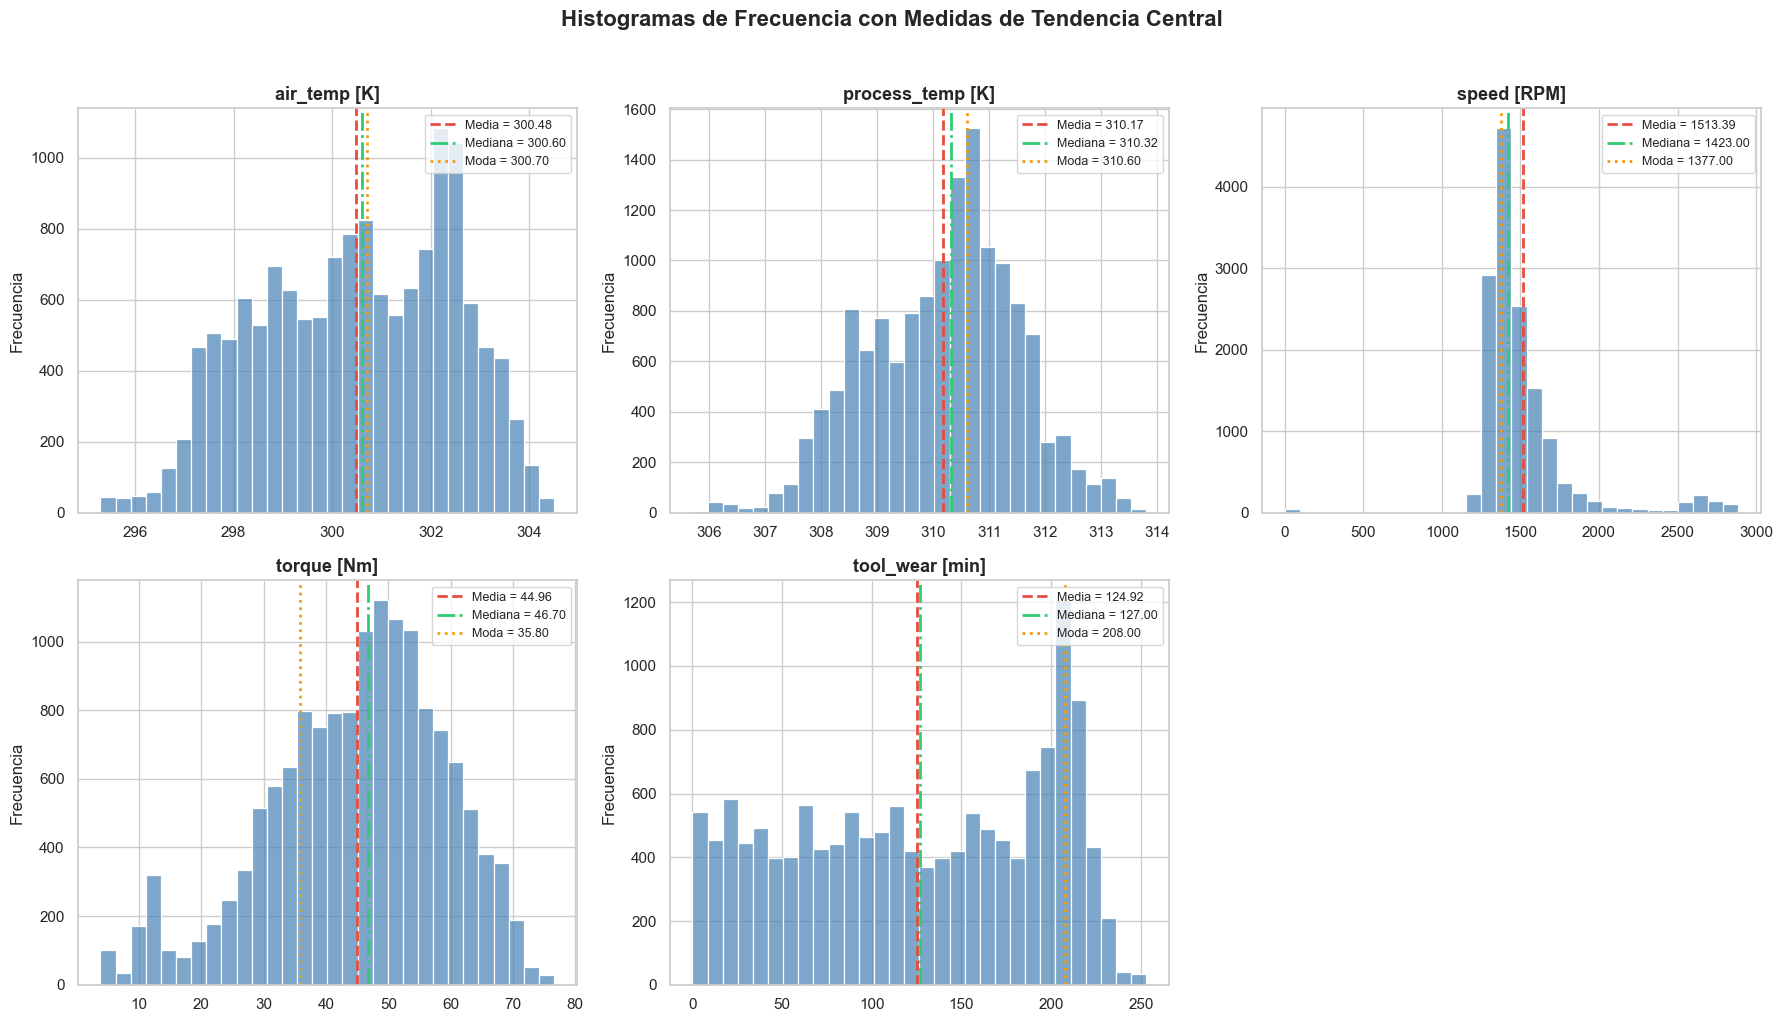

In [35]:
# --- Histogramas con medidas de tendencia central para cada columna numérica ---

# Seleccionar únicamente las columnas numéricas relevantes (excluimos idx y parent_device_id)
columnas_numericas = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]

    # Histograma (frecuencia absoluta)
    sns.histplot(df[col], bins=30, kde=False, color='steelblue', edgecolor='white',
                 alpha=0.7, ax=ax, stat='count')

    # Cálculo de medidas de tendencia central
    media   = df[col].mean()
    mediana = df[col].median()
    moda    = df[col].mode()[0]

    # Líneas verticales para cada medida
    ax.axvline(media,   color='#e74c3c', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
    ax.axvline(mediana, color='#2ecc71', linestyle='-.',  linewidth=2, label=f'Mediana = {mediana:.2f}')
    ax.axvline(moda,    color='#f39c12', linestyle=':',   linewidth=2, label=f'Moda = {moda:.2f}')

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9, loc='upper right')

# Ocultar el subplot vacío (tenemos 5 gráficos en una grilla de 2x3)
axes[-1].set_visible(False)

fig.suptitle('Histogramas de Frecuencia con Medidas de Tendencia Central', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Proporciones de las columnas categóricas

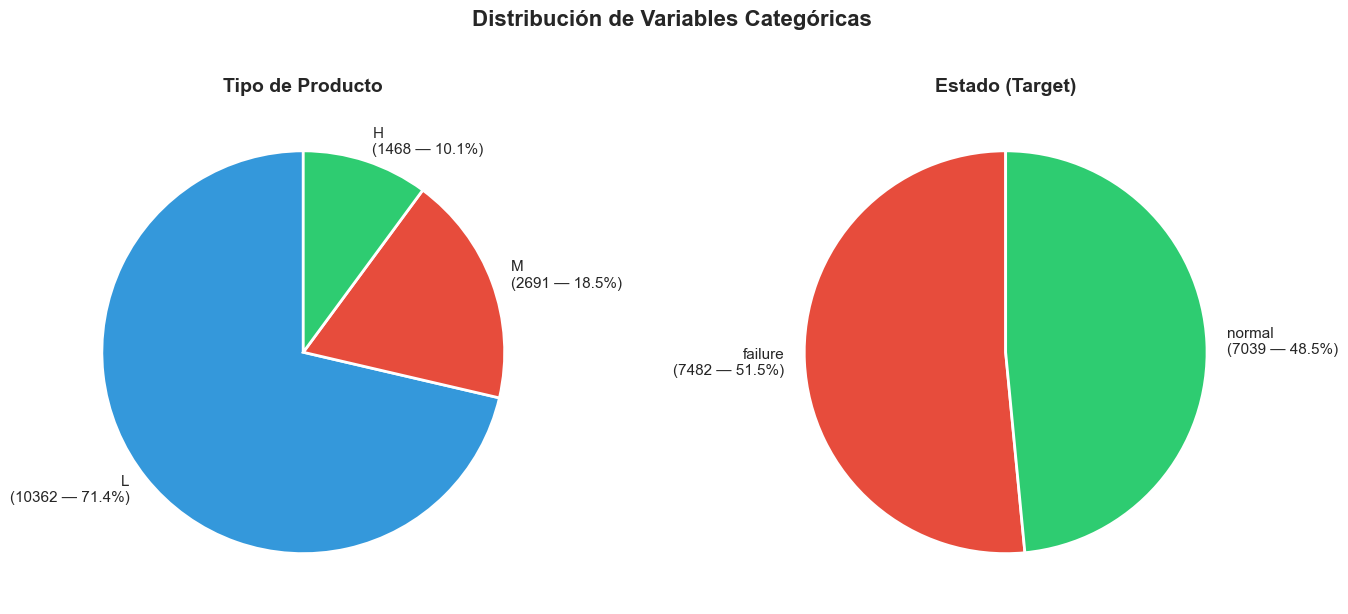

In [34]:
# --- Gráficos de proporciones para las columnas categóricas ---

columnas_categoricas = ['product_type', 'target']
titulos = ['Tipo de Producto', 'Estado (Target)']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Paletas de colores
paletas = [
    ['#3498db', '#e74c3c', '#2ecc71'],   # product_type: L, M, H
    ['#e74c3c', '#2ecc71']               # target: failure, normal
]

for i, col in enumerate(columnas_categoricas):
    ax = axes[i]
    conteos = df[col].value_counts()
    proporciones = conteos / conteos.sum() * 100

    # Etiquetas con conteo y porcentaje
    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos.index, conteos.values, proporciones.values)]

    wedges, texts = ax.pie(
        conteos.values,
        labels=etiquetas,
        colors=paletas[i],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    # Ajustar tamaño de fuente de etiquetas
    for t in texts:
        t.set_fontsize(11)

    ax.set_title(titulos[i], fontsize=14, fontweight='bold')

fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Medidas de dispersión
#### Tabla resumen de medidas de dispersión

In [33]:
# --- Tabla resumen de medidas de dispersión ---

columnas_numericas = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

resumen = pd.DataFrame({
    'Variable':   columnas_numericas,
    'Mínimo':     [df[c].min()                              for c in columnas_numericas],
    'Máximo':     [df[c].max()                              for c in columnas_numericas],
    'Rango':      [df[c].max() - df[c].min()                for c in columnas_numericas],
    'Q1':         [df[c].quantile(0.25)                     for c in columnas_numericas],
    'Q3':         [df[c].quantile(0.75)                     for c in columnas_numericas],
    'IQR':        [df[c].quantile(0.75) - df[c].quantile(0.25) for c in columnas_numericas],
    'Varianza':   [df[c].var()                              for c in columnas_numericas],
    'Desv. Est.': [df[c].std()                              for c in columnas_numericas],
    'CV (%)':     [df[c].std() / df[c].mean() * 100         for c in columnas_numericas]
}).set_index('Variable')

# Mostrar la tabla con 2 decimales
resumen.round(2)

,Mínimo,Máximo,Rango,Q1,Q3,IQR,Varianza,Desv. Est.,CV (%)
Variable,,,,,,,,,
air_temp [K],295.3,304.5,9.2,298.90,302.20,3.30,3.81,1.95,0.65
process_temp [K],305.7,313.8,8.1,309.20,311.09,1.89,1.77,1.33,0.43
speed [RPM],-1.0,2886.0,2887.0,1354.00,1561.00,207.00,98347.58,313.60,20.72
torque [Nm],3.8,76.6,72.8,35.99,55.00,19.01,202.40,14.23,31.65
tool_wear [min],0.0,253.0,253.0,64.00,193.00,129.00,4914.85,70.11,56.12


#### Diagramas de caja (Box Plots)

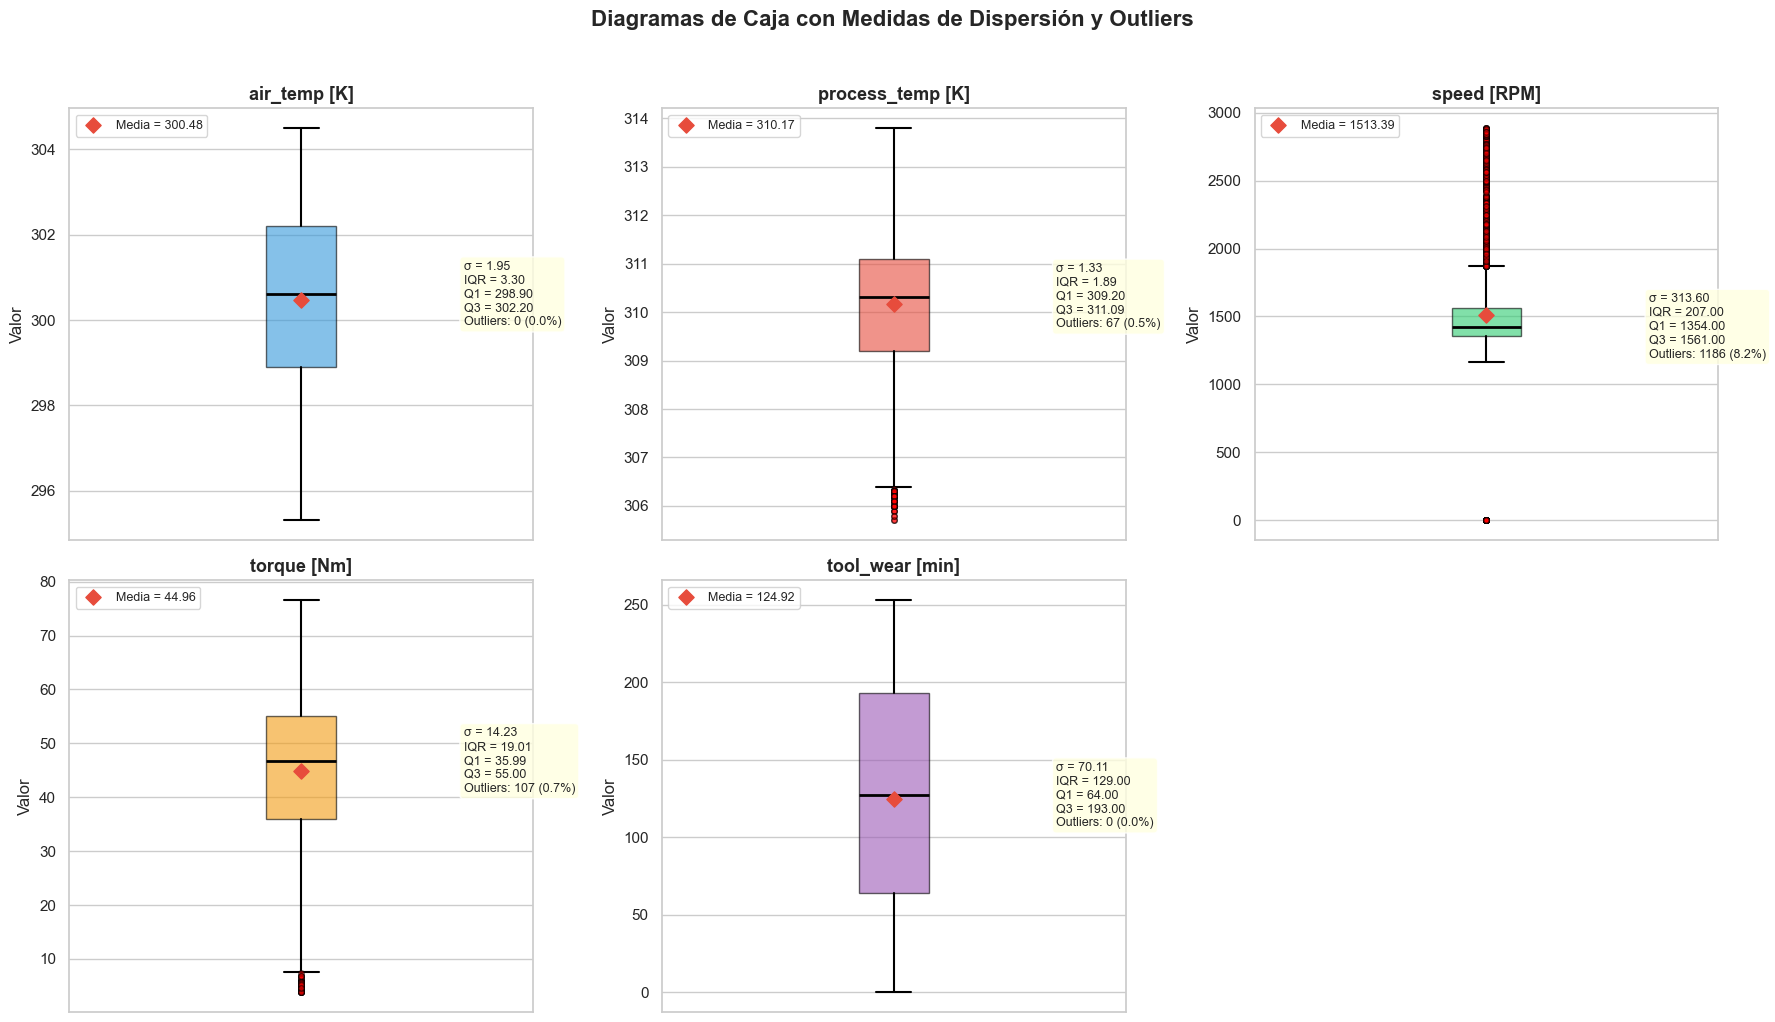

In [32]:
# --- Box Plots para cada variable numérica (con conteo de outliers) ---

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

colores_box = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, col in enumerate(columnas_numericas):
    ax = axes[i]

    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colores_box[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

    # Estadísticas
    media   = df[col].mean()
    std     = df[col].std()
    mediana = df[col].median()
    q1      = df[col].quantile(0.25)
    q3      = df[col].quantile(0.75)
    iqr     = q3 - q1

    # Contar outliers (método IQR: valores fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out   = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    pct_out = n_out / len(df) * 100

    # Marcar la media con un diamante
    ax.scatter([1], [media], marker='D', color='#e74c3c', s=60, zorder=5, label=f'Media = {media:.2f}')

    # Texto con estadísticas de dispersión + outliers
    stats_text = (f'σ = {std:.2f}\n'
                  f'IQR = {iqr:.2f}\n'
                  f'Q1 = {q1:.2f}\n'
                  f'Q3 = {q3:.2f}\n'
                  f'Outliers: {n_out} ({pct_out:.1f}%)')
    ax.text(1.35, mediana, stats_text, fontsize=9, va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xticks([])
    ax.legend(fontsize=9, loc='upper left')

# Ocultar el subplot vacío
axes[-1].set_visible(False)

fig.suptitle('Diagramas de Caja con Medidas de Dispersión y Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Análisis de correlación

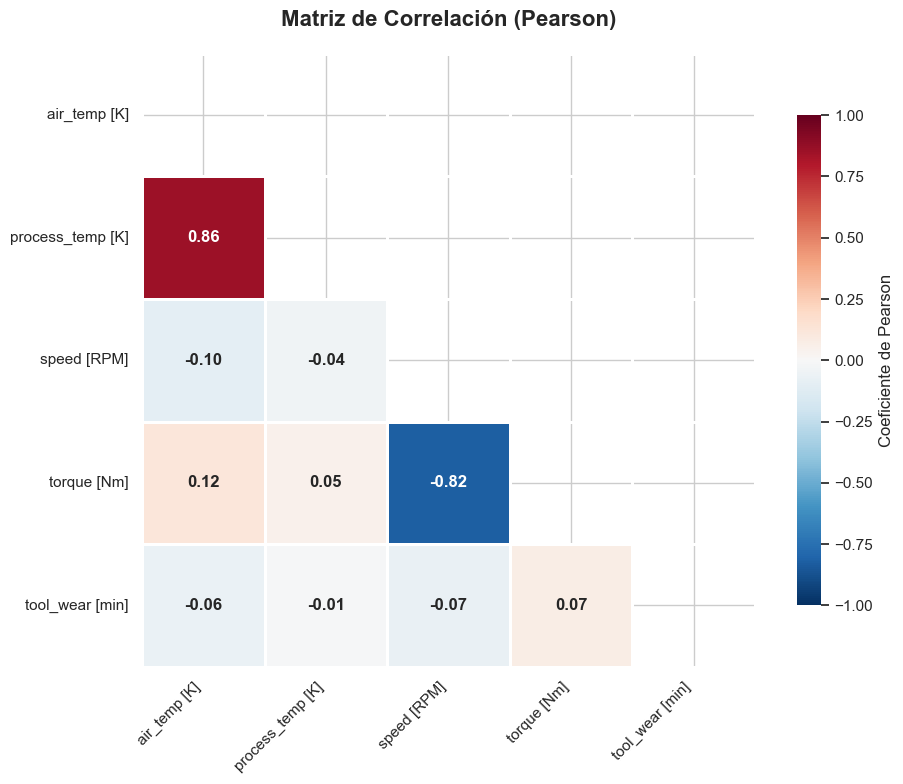

In [31]:
# --- Heatmap de la matriz de correlación (Pearson) ---

# Calcular la matriz de correlación solo para las columnas numéricas relevantes
corr_matrix = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Crear máscara para el triángulo superior (evitar redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Coeficiente de Pearson', 'shrink': 0.8})

ax.set_title('Matriz de Correlación (Pearson)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

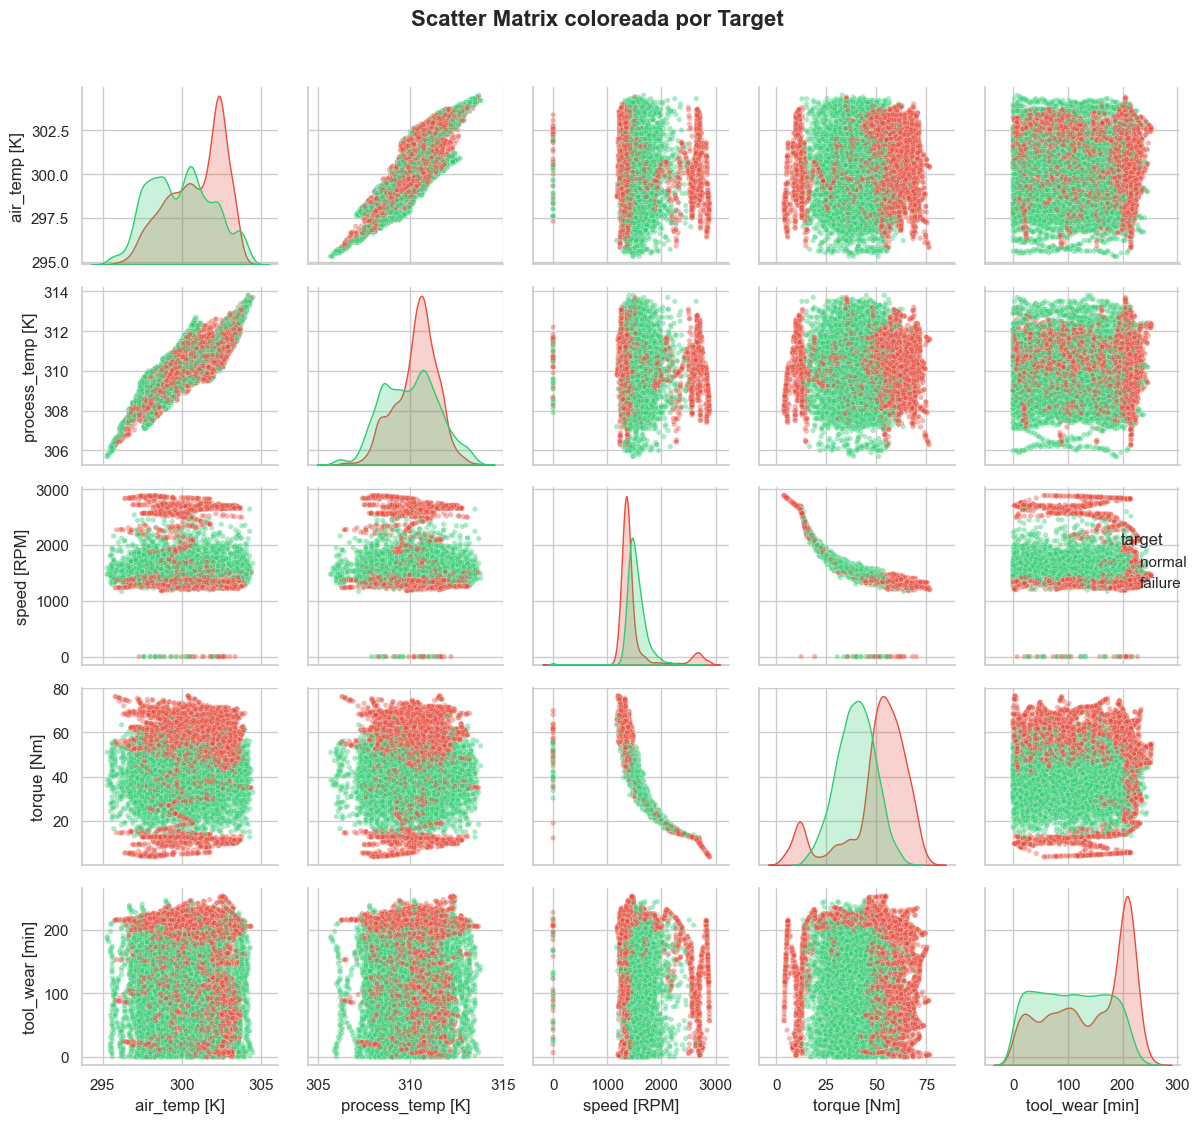

In [30]:
# --- Pairplot (scatter matrix) coloreado por la variable target ---

g = sns.pairplot(df[columnas_numericas + ['target']], hue='target',
                 palette={'failure': '#e74c3c', 'normal': '#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 height=2.2)

g.figure.suptitle('Scatter Matrix coloreada por Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()